# **Imports + Config + Seed**

In [7]:
import os
import json
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import confusion_matrix, classification_report
import torch.nn as nn

# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# Device
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Config
# =========================
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 43

TRAIN_PATH = "../dataset/train"
VAL_PATH = "../dataset/val"
TEST_PATH = "../dataset/test"

# =========================
# Output dirs
# =========================
os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/logs", exist_ok=True)

# **Transforms**

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# **Load Dataset**

In [9]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_transform)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 33318
Val: 5891
Test: 12630


# **Class Weights + Sampler**

In [10]:
labels = [label for _, label in train_dataset]
class_counts = np.bincount(labels)

weights = 1. / class_counts
sample_weights = [weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

# **DataLoaders**

In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# **Model**

In [12]:
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)
model = model.to(DEVICE)

# **Freeze Layers**

In [13]:
for param in model.features.parameters():
    param.requires_grad = False

# **Loss + Optimizer + Scheduler**

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.3
)

# **Training Loop**

In [15]:
train_losses = []
val_accuracies = []

best_acc = 0
patience = 3
counter = 0

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # ================= VALIDATION =================
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Val Acc: {acc:.4f}")

    # ================= SCHEDULER =================
    scheduler.step()

    # ================= EARLY STOPPING =================
    if counter >= patience:
        print("⛔ Early stopping")
        break

    # ================= UNFREEZE =================
    if epoch == 4:
        for param in model.features.parameters():
            param.requires_grad = True
        print("🔥 Unfroze backbone")

Epoch 1 | Loss: 2.3997 | Val Acc: 0.2375
✅ Saved best model
Epoch 2 | Loss: 1.5654 | Val Acc: 0.3395
✅ Saved best model
Epoch 3 | Loss: 1.2757 | Val Acc: 0.4054
✅ Saved best model
Epoch 4 | Loss: 1.1582 | Val Acc: 0.4252
✅ Saved best model
Epoch 5 | Loss: 1.1149 | Val Acc: 0.4371
✅ Saved best model
🔥 Unfroze backbone
Epoch 6 | Loss: 0.2277 | Val Acc: 0.9211
✅ Saved best model
Epoch 7 | Loss: 0.0530 | Val Acc: 0.9482
✅ Saved best model
Epoch 8 | Loss: 0.0354 | Val Acc: 0.9593
✅ Saved best model
Epoch 9 | Loss: 0.0245 | Val Acc: 0.9730
✅ Saved best model
Epoch 10 | Loss: 0.0178 | Val Acc: 0.9779
✅ Saved best model
Epoch 11 | Loss: 0.0154 | Val Acc: 0.9767
Epoch 12 | Loss: 0.0140 | Val Acc: 0.9801
✅ Saved best model
Epoch 13 | Loss: 0.0126 | Val Acc: 0.9808
✅ Saved best model
Epoch 14 | Loss: 0.0111 | Val Acc: 0.9812
✅ Saved best model
Epoch 15 | Loss: 0.0117 | Val Acc: 0.9835
✅ Saved best model


# **Save Training Curves**

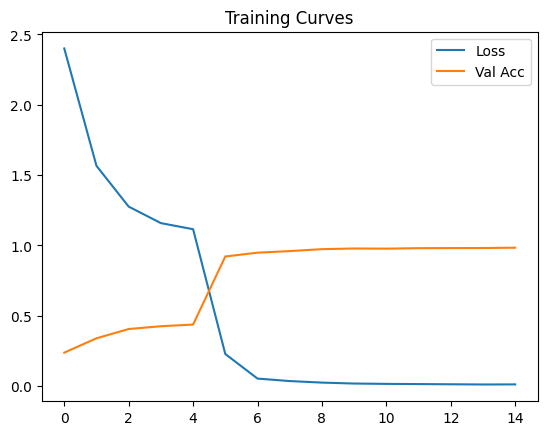

In [16]:
plt.figure()
plt.plot(train_losses, label="Loss")
plt.plot(val_accuracies, label="Val Acc")
plt.legend()
plt.title("Training Curves")

plt.savefig("outputs/plots/curves.png", dpi=300)
plt.show()

# **Test + Confusion Matrix**

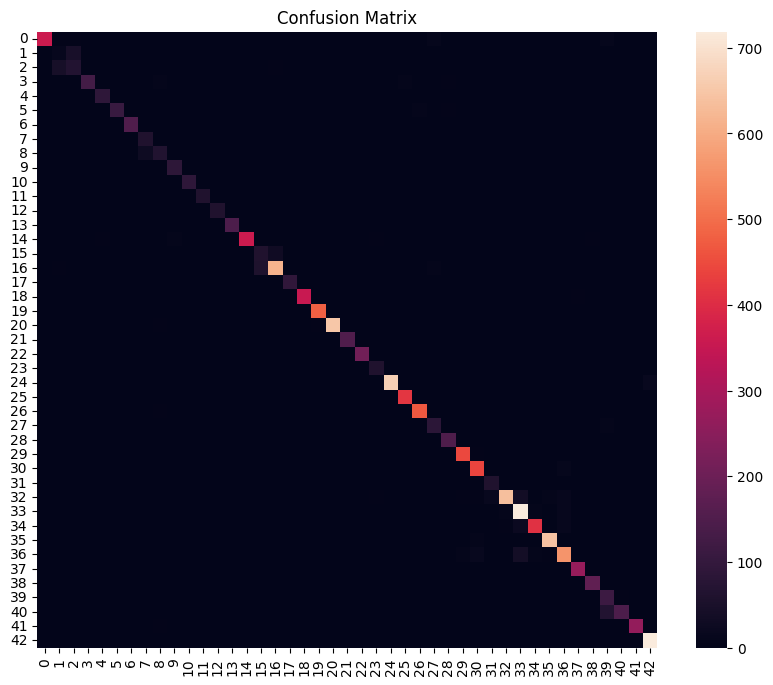

In [17]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm)
plt.title("Confusion Matrix")

plt.savefig("outputs/plots/cm.png", dpi=300)
plt.show()

# **Classification Report**

In [18]:
report = classification_report(all_labels, all_preds, output_dict=True)

with open("outputs/logs/report.json", "w") as f:
    json.dump(report, f, indent=4)

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96       390
           1       0.20      0.22      0.21        60
           2       0.54      0.56      0.55       120
           3       0.98      0.85      0.91       150
           4       0.95      0.99      0.97        90
           5       0.98      0.90      0.94       120
           6       0.99      0.99      0.99       150
           7       0.67      1.00      0.80        60
           8       0.68      0.69      0.69        90
           9       0.88      0.97      0.92        90
          10       0.99      0.99      0.99        90
          11       1.00      1.00      1.00        60
          12       1.00      1.00      1.00        60
          13       0.99      0.97      0.98       150
          14       0.99      0.93      0.96       390
          15       0.50      0.67      0.57        90
          16       0.95      0.89      0.92       690
          17       0.96    

# **Top-5 Accuracy**

In [19]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        _, preds = outputs.topk(5, dim=1)

        for i in range(len(labels)):
            if labels[i] in preds[i]:
                correct += 1

        total += labels.size(0)

print("Top-5 Accuracy:", correct / total)

Top-5 Accuracy: 0.9963578780680918


# **Save Model**

In [22]:
========================
torch.save({

    "model_state_dict": model.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),

    "model_name": "mobilenet_v2",
    "num_classes": NUM_CLASSES,
    "image_size": 224,

    "epoch": epoch,
    "best_acc": best_acc,

    "class_to_idx": train_dataset.class_to_idx,

    "seed": SEED

}, "outputs/model/mobilenetv2_full.pth")

print("✅ Full checkpoint saved")

torch.save(
    model.state_dict(),
    "outputs/model/mobilenetv2_inference.pth"
)

print("✅ Inference model saved")

✅ Full checkpoint saved
✅ Inference model saved


# **Save Experiment Config**

In [21]:
config = {
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": 0.001,
    "model": "mobilenet_v2",
    "num_classes": NUM_CLASSES,
    "seed": SEED
}

with open("outputs/logs/config.json", "w") as f:
    json.dump(config, f, indent=4)